# 01. 같은 구 내 이동 상세 분석

탑승완료 데이터를 기준으로 `출발구 == 목적구`인 서울 자치구 내 이동을 상세히 분석한다.
구별 이동 건수, 같은 구 내 이동 비율, 승차거리, 대기시간을 함께 확인하여 구 내 이동 수요가 큰 지역과 그 특성을 파악한다.


## 1. 데이터 로드

정제된 탑승내역 데이터를 불러온다. 노트북 실행 위치가 프로젝트 루트이거나 `notebooks_kms/` 내부인 경우 모두 동작하도록 프로젝트 루트와 데이터 경로를 설정한다.


In [15]:
import platform
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

boarding_path = PROCESSED_DIR / "서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv"
print(boarding_path)

df = pd.read_csv(boarding_path)
print(f"전체 행 수: {len(df):,}")
display(df.head())


c:\Users\young\my_project\260901_call_taxi_DA\data\processed\서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv
전체 행 수: 1,722,490


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,기타,NaN,0,특장차,뇌병
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체


## 2. 탑승완료 필터링

이동 흐름 분석은 실제 승차와 하차가 완료된 건을 기준으로 한다. `승차일시`와 `하차일시`가 있고 `취소일시`가 없는 행만 탑승완료 데이터로 분리한다.


In [16]:
completed = df[
    df["승차일시"].notna()
    & df["하차일시"].notna()
    & df["취소일시"].isna()
].copy()

print(f"탑승완료 건수: {len(completed):,} / 전체 {len(df):,} ({len(completed) / len(df) * 100:.1f}%)")
display(completed.head())


탑승완료 건수: 1,477,067 / 전체 1,722,490 (85.8%)


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체
5,2025-01-01 00:05:54.000,2025-01-01 00:06:00.000,2025-01-01 00:16:19.457,2025-01-01 00:54:19.940,2025-01-01 01:11:02.643,NaN,서초구,서초3동,서초구,반포2동,귀가,1700.0,5205,특장차,뇌병


## 3. 서울 25개구 필터링

서울 자치구 내 이동만 분석하기 위해 출발구와 목적구가 모두 서울 25개 자치구에 포함되는 탑승완료 건을 분리한다.


In [17]:
SEOUL_25 = [
    "강남구", "강동구", "강북구", "강서구", "관악구",
    "광진구", "구로구", "금천구", "노원구", "도봉구",
    "동대문구", "동작구", "마포구", "서대문구", "서초구",
    "성동구", "성북구", "송파구", "양천구", "영등포구",
    "용산구", "은평구", "종로구", "중구", "중랑구",
]

seoul_completed = completed[
    completed["출발구"].isin(SEOUL_25)
    & completed["목적구"].isin(SEOUL_25)
].copy()

print(f"서울 25개구 내 탑승완료 건수: {len(seoul_completed):,}")
print(f"전체 탑승완료 대비 비율: {len(seoul_completed) / len(completed) * 100:.1f}%")
print(f"집계 출발구 수: {seoul_completed['출발구'].nunique():,}개")
print(f"집계 목적구 수: {seoul_completed['목적구'].nunique():,}개")


서울 25개구 내 탑승완료 건수: 1,362,668
전체 탑승완료 대비 비율: 92.3%
집계 출발구 수: 25개
집계 목적구 수: 25개


## 4. 같은 구 내 이동 추출

`출발구`와 `목적구`가 같은 행만 추출한다. 이 데이터는 서울 자치구 내부에서 발생한 탑승완료 이동을 의미한다.


In [18]:
same_gu_seoul = seoul_completed[
    seoul_completed["출발구"] == seoul_completed["목적구"]
].copy()

diff_gu_seoul = seoul_completed[
    seoul_completed["출발구"] != seoul_completed["목적구"]
].copy()

print(f"서울→서울 탑승완료 건수: {len(seoul_completed):,}")
print(f"같은 구 내 이동 건수: {len(same_gu_seoul):,} ({len(same_gu_seoul) / len(seoul_completed) * 100:.1f}%)")
print(f"다른 구 간 이동 건수: {len(diff_gu_seoul):,} ({len(diff_gu_seoul) / len(seoul_completed) * 100:.1f}%)")
display(same_gu_seoul.head())


서울→서울 탑승완료 건수: 1,362,668
같은 구 내 이동 건수: 526,105 (38.6%)
다른 구 간 이동 건수: 836,563 (61.4%)


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
5,2025-01-01 00:05:54.000,2025-01-01 00:06:00.000,2025-01-01 00:16:19.457,2025-01-01 00:54:19.940,2025-01-01 01:11:02.643,NaN,서초구,서초3동,서초구,반포2동,귀가,1700.0,5205,특장차,뇌병
8,2025-01-01 00:07:46.960,2025-01-01 00:07:46.960,2025-01-01 00:17:21.880,2025-01-01 00:59:50.053,2025-01-01 01:14:38.393,NaN,강동구,상일동,강동구,성내제2동,기타,1500.0,4858,특장차,지체
14,2025-01-01 00:28:16.000,2025-01-01 00:29:00.000,2025-01-01 00:51:49.830,2025-01-01 01:06:28.367,2025-01-01 01:23:49.853,NaN,노원구,중계2.3동,노원구,상계1동,귀가,1700.0,5145,특장차,지체
22,2025-01-01 00:35:15.590,2025-01-01 00:35:15.590,2025-01-01 01:30:10.833,2025-01-01 01:43:59.510,2025-01-01 01:45:53.560,NaN,노원구,상계3.4동,노원구,상계3.4동,기타,1500.0,653,특장차,뇌병


## 5. 같은 구 내 이동 건수 순위

자치구별 같은 구 내 이동 건수를 집계한다. 같은 구 내 이동 건수가 많은 지역은 자치구 내부에서 반복적으로 이동 수요가 발생하는 지역으로 볼 수 있다.


,자치구,같은구_이동건수
0,노원구,83566
1,강서구,48447
2,강동구,46776
3,은평구,32986
4,중랑구,23550
5,서대문구,22965
6,마포구,21954
7,송파구,21221
8,관악구,21191
9,양천구,20979


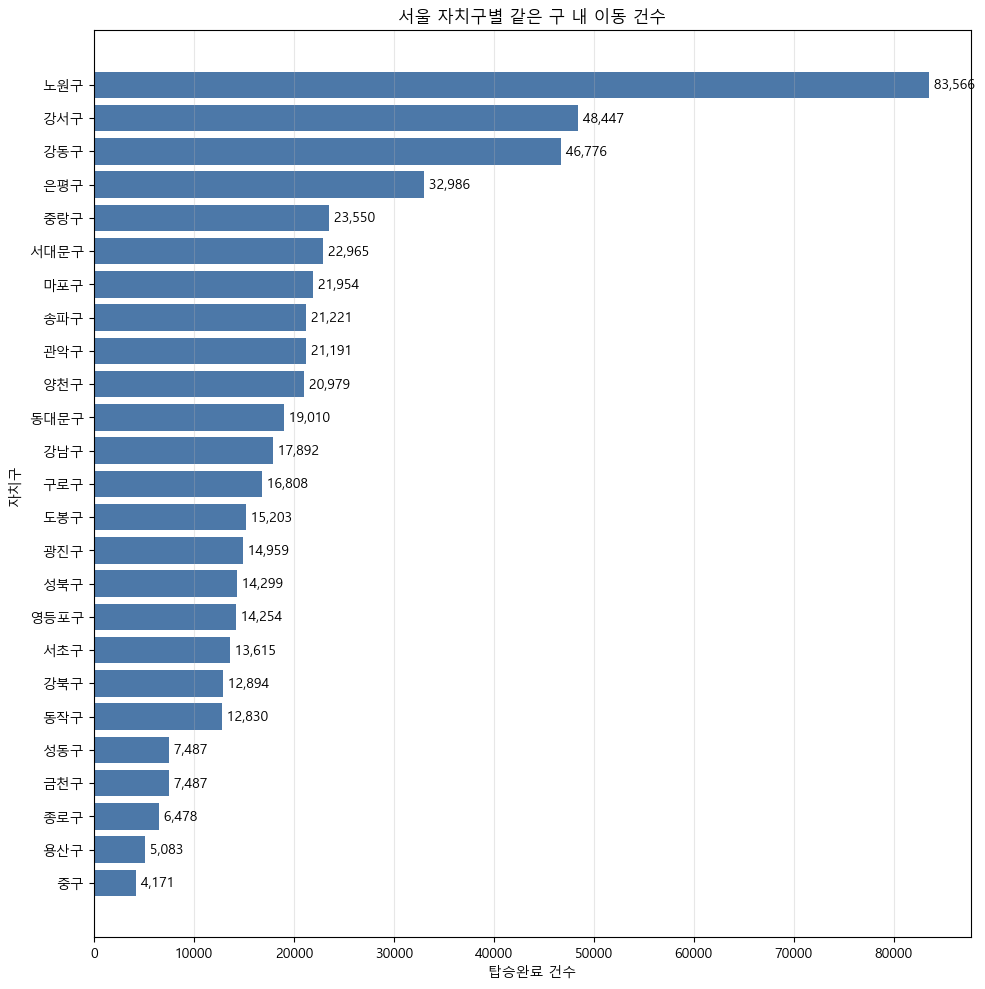

In [19]:
same_gu_rank = (
    same_gu_seoul
    .groupby("출발구")
    .size()
    .reindex(SEOUL_25, fill_value=0)
    .rename("같은구_이동건수")
    .reset_index()
    .rename(columns={"출발구": "자치구"})
    .sort_values("같은구_이동건수", ascending=False)
    .reset_index(drop=True)
)

display(same_gu_rank)

plot_data = same_gu_rank.sort_values("같은구_이동건수", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(plot_data["자치구"], plot_data["같은구_이동건수"], color="#4c78a8")
ax.set_title("서울 자치구별 같은 구 내 이동 건수")
ax.set_xlabel("탑승완료 건수")
ax.set_ylabel("자치구")
ax.grid(axis="x", alpha=0.3)

for index, value in enumerate(plot_data["같은구_이동건수"]):
    ax.text(value, index, f" {value:,.0f}", va="center")

plt.tight_layout()
plt.show()


## 6. 같은 구 내 이동 비율

각 자치구에서 출발한 서울 내 이동 중 같은 구 안에서 끝난 이동의 비율을 계산한다. 이 비율이 높으면 해당 자치구 내부 생활권 이동이 상대적으로 강하다고 볼 수 있다.


,자치구,서울내_출발건수,같은구_이동건수,같은구_이동비율(%)
0,강동구,79032,46776,59.19
1,노원구,151013,83566,55.34
2,강서구,92168,48447,52.56
3,은평구,71896,32986,45.88
4,관악구,49604,21191,42.72
5,중랑구,56188,23550,41.91
6,양천구,50890,20979,41.22
7,송파구,54085,21221,39.24
8,광진구,39692,14959,37.69
9,서초구,36276,13615,37.53


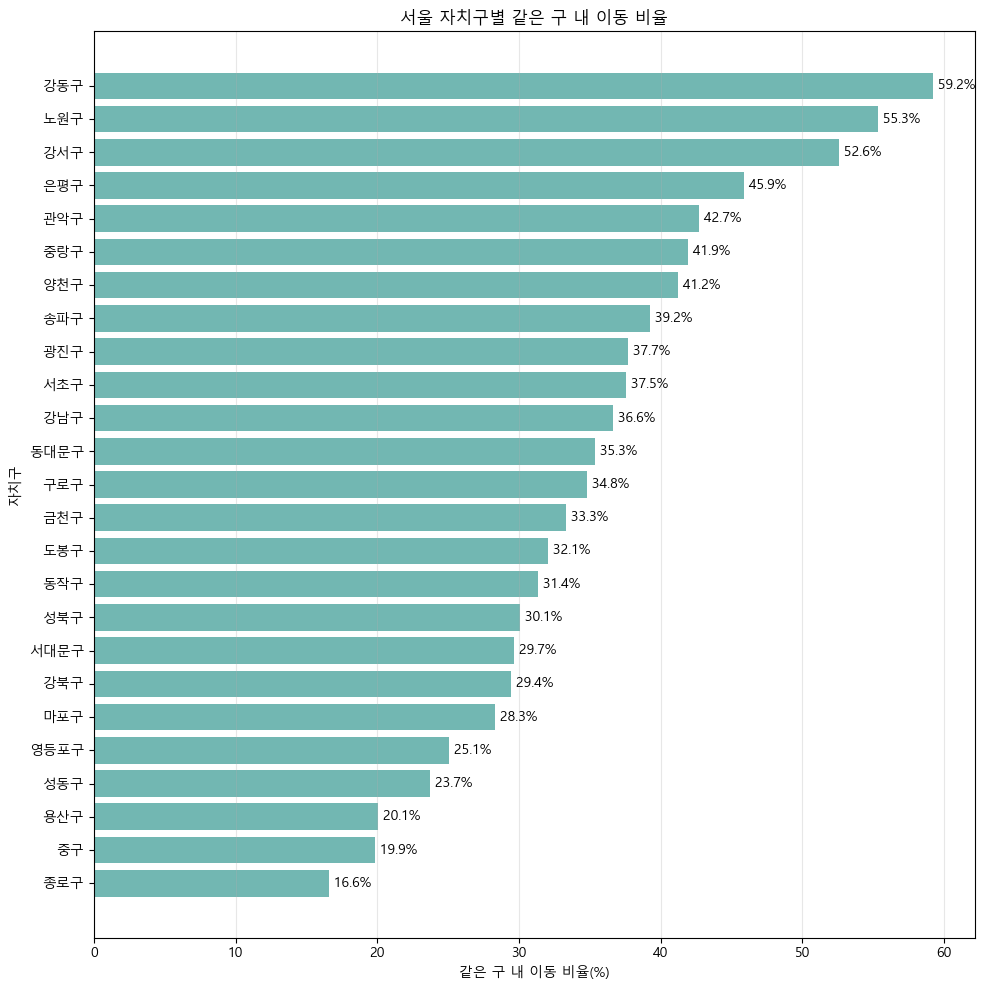

In [20]:
origin_total = (
    seoul_completed
    .groupby("출발구")
    .size()
    .reindex(SEOUL_25, fill_value=0)
    .rename("서울내_출발건수")
)

same_gu_count = (
    same_gu_seoul
    .groupby("출발구")
    .size()
    .reindex(SEOUL_25, fill_value=0)
    .rename("같은구_이동건수")
)

same_gu_ratio = pd.concat([origin_total, same_gu_count], axis=1).reset_index()
same_gu_ratio = same_gu_ratio.rename(columns={"출발구": "자치구"})
same_gu_ratio["같은구_이동비율(%)"] = (
    same_gu_ratio["같은구_이동건수"] / same_gu_ratio["서울내_출발건수"] * 100
).round(2)

same_gu_ratio = same_gu_ratio.sort_values("같은구_이동비율(%)", ascending=False).reset_index(drop=True)

display(same_gu_ratio)

plot_data = same_gu_ratio.sort_values("같은구_이동비율(%)", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(plot_data["자치구"], plot_data["같은구_이동비율(%)"], color="#72b7b2")
ax.set_title("서울 자치구별 같은 구 내 이동 비율")
ax.set_xlabel("같은 구 내 이동 비율(%)")
ax.set_ylabel("자치구")
ax.grid(axis="x", alpha=0.3)

for index, value in enumerate(plot_data["같은구_이동비율(%)"]):
    ax.text(value, index, f" {value:.1f}%", va="center")

plt.tight_layout()
plt.show()


## 7. 구별 승차거리 평균·중앙값

같은 구 내 이동이라도 자치구 면적과 생활권 구조에 따라 실제 이동거리는 다를 수 있다. 자치구별 승차거리 평균과 중앙값을 비교해 “같은 구 이동은 항상 짧다”는 단순 해석을 피한다.


,자치구,같은구_이동건수,평균승차거리,중앙값승차거리,p90승차거리
0,서초구,13615,4062.910246,3687.0,6694.2
1,구로구,16808,3695.363696,3451.5,6589.3
2,송파구,21221,3750.436360,3288.0,6695.0
3,강서구,48447,3260.606642,3225.0,5091.0
4,강남구,17892,3803.946457,3171.0,7253.9
5,서대문구,22965,3275.103244,3137.0,5208.0
6,양천구,20979,3278.194242,3093.0,5418.0
7,강동구,46776,3288.723042,3067.0,5826.0
8,종로구,6478,3076.986416,2930.0,5056.6
9,동작구,12830,3154.654248,2775.0,5469.1


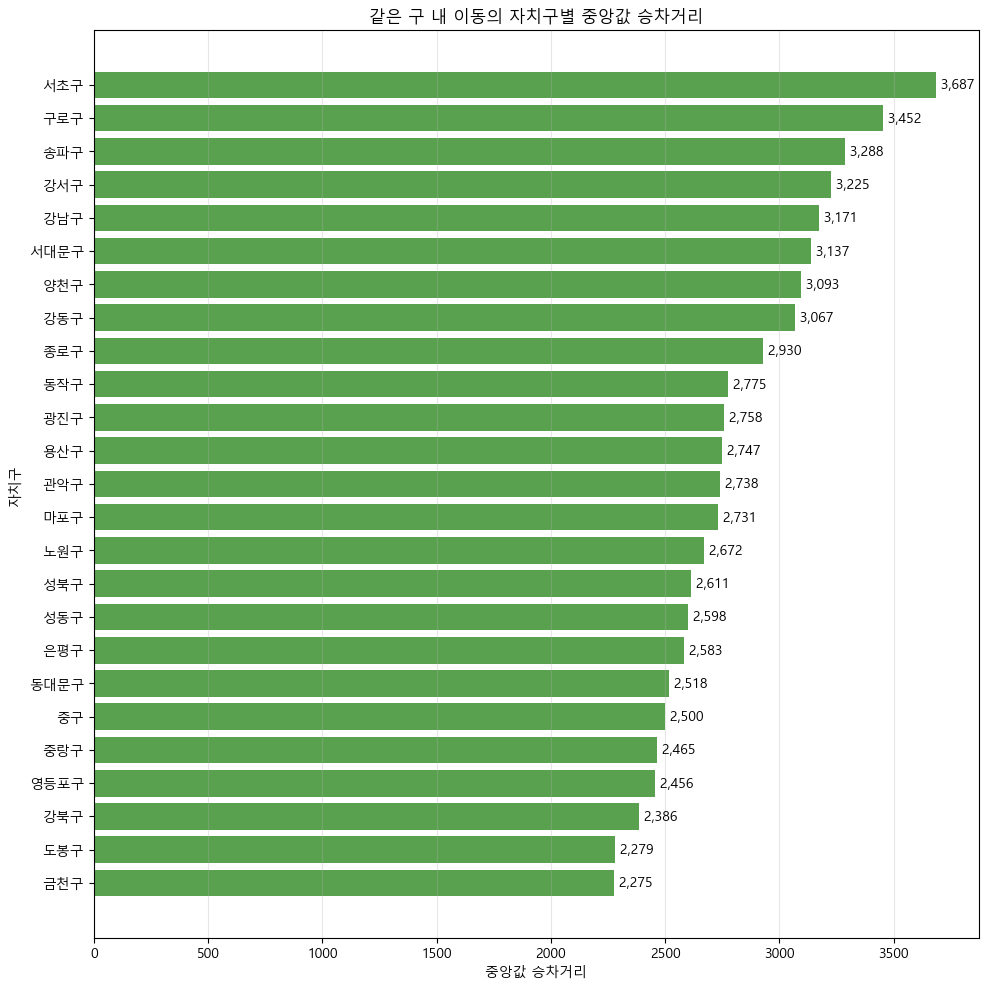

In [21]:
same_gu_distance_summary = (
    same_gu_seoul
    .assign(승차거리=pd.to_numeric(same_gu_seoul["승차거리"], errors="coerce"))
    .groupby("출발구")
    .agg(
        같은구_이동건수=("승차거리", "size"),
        평균승차거리=("승차거리", "mean"),
        중앙값승차거리=("승차거리", "median"),
        p90승차거리=("승차거리", lambda s: s.quantile(0.9)),
    )
    .reindex(SEOUL_25)
    .reset_index()
    .rename(columns={"출발구": "자치구"})
    .sort_values("중앙값승차거리", ascending=False)
    .reset_index(drop=True)
)

display(same_gu_distance_summary)

plot_data = same_gu_distance_summary.sort_values("중앙값승차거리", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(plot_data["자치구"], plot_data["중앙값승차거리"], color="#59a14f")
ax.set_title("같은 구 내 이동의 자치구별 중앙값 승차거리")
ax.set_xlabel("중앙값 승차거리")
ax.set_ylabel("자치구")
ax.grid(axis="x", alpha=0.3)

for index, value in enumerate(plot_data["중앙값승차거리"]):
    if pd.notna(value):
        ax.text(value, index, f" {value:,.0f}", va="center")

plt.tight_layout()
plt.show()


## 8. 구별 대기시간 평균·중앙값

같은 구 내 이동의 대기시간을 `접수→배차`, `배차→승차`, `접수→승차`로 나누어 계산한다. 이를 통해 같은 구 이동이 많은 자치구에서 어떤 단계의 대기시간이 긴지 확인한다.


음수 대기시간 행 수: 0건


,자치구,같은구_이동건수,평균_접수배차분,중앙값_접수배차분,평균_배차승차분,중앙값_배차승차분,평균_접수승차분,중앙값_접수승차분
0,서초구,13615,70.210756,22.700900,21.683392,20.501400,91.894148,45.234167
1,관악구,21191,57.265179,18.791950,19.735611,18.963217,77.000790,40.352400
2,강남구,17892,82.582277,17.466975,20.156796,19.312117,102.739073,39.417717
3,용산구,5083,52.276538,13.620000,20.883390,20.013717,73.159928,37.584767
4,중구,4171,29.128819,12.898900,21.469721,20.660233,50.598539,37.176000
5,성동구,7487,81.321620,14.652050,19.960362,19.271883,101.281982,36.747117
6,동작구,12830,74.810889,14.541608,19.287815,18.755558,94.098704,36.216750
7,성북구,14299,40.715841,12.554500,19.766310,18.957833,60.482151,35.467783
8,종로구,6478,49.451068,11.965750,19.745100,19.157975,69.196168,35.316417
9,구로구,16808,102.063645,13.576083,19.275126,18.564825,121.338771,35.187108


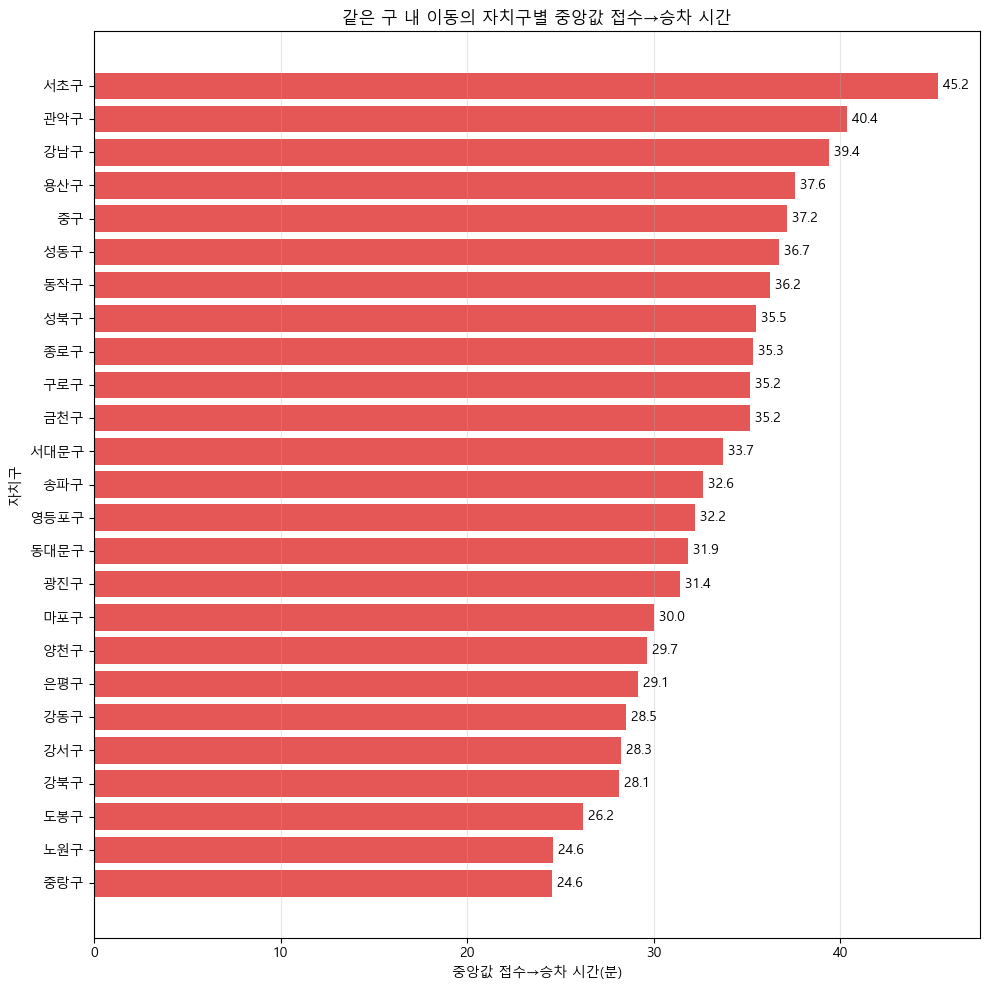

In [22]:
same_gu_wait = same_gu_seoul.copy()

for col in ["접수일시", "배차일시", "승차일시"]:
    same_gu_wait[col] = pd.to_datetime(same_gu_wait[col], errors="coerce")

same_gu_wait["접수_배차_분"] = (
    same_gu_wait["배차일시"] - same_gu_wait["접수일시"]
).dt.total_seconds() / 60

same_gu_wait["배차_승차_분"] = (
    same_gu_wait["승차일시"] - same_gu_wait["배차일시"]
).dt.total_seconds() / 60

same_gu_wait["접수_승차_분"] = (
    same_gu_wait["승차일시"] - same_gu_wait["접수일시"]
).dt.total_seconds() / 60

wait_cols = ["접수_배차_분", "배차_승차_분", "접수_승차_분"]

invalid_wait_count = same_gu_wait[wait_cols].lt(0).any(axis=1).sum()
for col in wait_cols:
    same_gu_wait.loc[same_gu_wait[col] < 0, col] = pd.NA

print(f"음수 대기시간 행 수: {invalid_wait_count:,}건")

same_gu_wait_summary = (
    same_gu_wait
    .groupby("출발구")
    .agg(
        같은구_이동건수=("접수일시", "size"),
        평균_접수배차분=("접수_배차_분", "mean"),
        중앙값_접수배차분=("접수_배차_분", "median"),
        평균_배차승차분=("배차_승차_분", "mean"),
        중앙값_배차승차분=("배차_승차_분", "median"),
        평균_접수승차분=("접수_승차_분", "mean"),
        중앙값_접수승차분=("접수_승차_분", "median"),
    )
    .reindex(SEOUL_25)
    .reset_index()
    .rename(columns={"출발구": "자치구"})
    .sort_values("중앙값_접수승차분", ascending=False)
    .reset_index(drop=True)
)

display(same_gu_wait_summary)

plot_data = same_gu_wait_summary.sort_values("중앙값_접수승차분", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(plot_data["자치구"], plot_data["중앙값_접수승차분"], color="#e45756")
ax.set_title("같은 구 내 이동의 자치구별 중앙값 접수→승차 시간")
ax.set_xlabel("중앙값 접수→승차 시간(분)")
ax.set_ylabel("자치구")
ax.grid(axis="x", alpha=0.3)

for index, value in enumerate(plot_data["중앙값_접수승차분"]):
    if pd.notna(value):
        ax.text(value, index, f" {value:,.1f}", va="center")

plt.tight_layout()
plt.show()


## 9. 같은 구 내 이동이 많은 구 해석

같은 구 내 이동 건수, 같은 구 내 이동 비율, 승차거리, 대기시간을 함께 묶어 해석한다. 이동 건수가 많고 비율도 높은 지역은 자치구 내부 생활권 수요가 강한 지역으로 볼 수 있으며, 여기에 대기시간이 길게 나타나면 내부 수요 대응의 병목 후보로 볼 수 있다.


In [ ]:
same_gu_analysis = (
    same_gu_rank
    .merge(same_gu_ratio, on=["자치구", "같은구_이동건수"], how="left")
    .merge(
        same_gu_distance_summary[["자치구", "평균승차거리", "중앙값승차거리"]],
        on="자치구",
        how="left",
    )
    .merge(
        same_gu_wait_summary[[
            "자치구",
            "평균_접수배차분",
            "중앙값_접수배차분",
            "평균_배차승차분",
            "중앙값_배차승차분",
            "평균_접수승차분",
            "중앙값_접수승차분",
        ]],
        on="자치구",
        how="left",
    )
    .sort_values("같은구_이동건수", ascending=False)
    .reset_index(drop=True)
)

display(same_gu_analysis)

print("같은 구 내 이동 건수 상위 5개구")
display(same_gu_analysis.head(5))

print("같은 구 내 이동 비율 상위 5개구")
display(same_gu_analysis.sort_values("같은구_이동비율(%)", ascending=False).head(5))

print("같은 구 내 이동 중 접수→승차 중앙값이 긴 5개구")
display(same_gu_analysis.sort_values("중앙값_접수승차분", ascending=False).head(5))


,자치구,같은구_이동건수,서울내_출발건수,같은구_이동비율(%),평균승차거리,중앙값승차거리,평균_접수배차분,중앙값_접수배차분,평균_배차승차분,중앙값_배차승차분,평균_접수승차분,중앙값_접수승차분
0,노원구,83566,151013,55.34,2932.314805,2672.0,68.062113,9.211142,14.560142,13.654475,82.622256,24.606500
1,강서구,48447,92168,52.56,3260.606642,3225.0,77.666144,9.480833,17.175741,16.154283,94.841884,28.275450
2,강동구,46776,79032,59.19,3288.723042,3067.0,78.040686,10.351333,15.799164,14.959808,93.839849,28.516192
3,은평구,32986,71896,45.88,2924.047657,2583.0,54.285820,9.904083,16.563141,15.558217,70.848961,29.140142
4,중랑구,23550,56188,41.91,2682.441571,2465.0,29.509132,8.891558,15.513095,14.453333,45.022227,24.550892
5,서대문구,22965,77432,29.66,3275.103244,3137.0,75.349466,11.740550,18.623312,17.904667,93.972778,33.699833
6,마포구,21954,77582,28.30,3413.302633,2731.0,44.116759,10.335525,17.157099,16.454667,61.273858,30.004275
7,송파구,21221,54085,39.24,3750.436360,3288.0,77.300153,12.096950,18.305186,17.511433,95.605339,32.636217
8,관악구,21191,49604,42.72,2952.433627,2738.0,57.265179,18.791950,19.735611,18.963217,77.000790,40.352400
9,양천구,20979,50890,41.22,3278.194242,3093.0,69.045435,9.584217,18.443522,17.508400,87.488957,29.662617


같은 구 내 이동 건수 상위 5개구


,자치구,같은구_이동건수,서울내_출발건수,같은구_이동비율(%),평균승차거리,중앙값승차거리,평균_접수배차분,중앙값_접수배차분,평균_배차승차분,중앙값_배차승차분,평균_접수승차분,중앙값_접수승차분
0,노원구,83566,151013,55.34,2932.314805,2672.0,68.062113,9.211142,14.560142,13.654475,82.622256,24.606500
1,강서구,48447,92168,52.56,3260.606642,3225.0,77.666144,9.480833,17.175741,16.154283,94.841884,28.275450
2,강동구,46776,79032,59.19,3288.723042,3067.0,78.040686,10.351333,15.799164,14.959808,93.839849,28.516192
3,은평구,32986,71896,45.88,2924.047657,2583.0,54.285820,9.904083,16.563141,15.558217,70.848961,29.140142
4,중랑구,23550,56188,41.91,2682.441571,2465.0,29.509132,8.891558,15.513095,14.453333,45.022227,24.550892


같은 구 내 이동 비율 상위 5개구


,자치구,같은구_이동건수,서울내_출발건수,같은구_이동비율(%),평균승차거리,중앙값승차거리,평균_접수배차분,중앙값_접수배차분,평균_배차승차분,중앙값_배차승차분,평균_접수승차분,중앙값_접수승차분
2,강동구,46776,79032,59.19,3288.723042,3067.0,78.040686,10.351333,15.799164,14.959808,93.839849,28.516192
0,노원구,83566,151013,55.34,2932.314805,2672.0,68.062113,9.211142,14.560142,13.654475,82.622256,24.606500
1,강서구,48447,92168,52.56,3260.606642,3225.0,77.666144,9.480833,17.175741,16.154283,94.841884,28.275450
3,은평구,32986,71896,45.88,2924.047657,2583.0,54.285820,9.904083,16.563141,15.558217,70.848961,29.140142
8,관악구,21191,49604,42.72,2952.433627,2738.0,57.265179,18.791950,19.735611,18.963217,77.000790,40.352400


같은 구 내 이동 중 접수→승차 중앙값이 긴 5개구


,자치구,같은구_이동건수,서울내_출발건수,같은구_이동비율(%),평균승차거리,중앙값승차거리,평균_접수배차분,중앙값_접수배차분,평균_배차승차분,중앙값_배차승차분,평균_접수승차분,중앙값_접수승차분
17,서초구,13615,36276,37.53,4062.910246,3687.0,70.210756,22.700900,21.683392,20.501400,91.894148,45.234167
8,관악구,21191,49604,42.72,2952.433627,2738.0,57.265179,18.791950,19.735611,18.963217,77.000790,40.352400
11,강남구,17892,48834,36.64,3803.946457,3171.0,82.582277,17.466975,20.156796,19.312117,102.739073,39.417717
23,용산구,5083,25328,20.07,3030.248869,2747.0,52.276538,13.620000,20.883390,20.013717,73.159928,37.584767
24,중구,4171,20988,19.87,2706.162551,2500.0,29.128819,12.898900,21.469721,20.660233,50.598539,37.176000


: 